In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import math
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PROJECT = "/content/drive/MyDrive/Colab Notebooks/CSE499B_next_step"
CKPT_DIR = os.path.join(PROJECT, "checkpoints")
SAMPLE_DIR = os.path.join(PROJECT, "samples")
RESULT_DIR = os.path.join(PROJECT, "results")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Project folder ready:", PROJECT)

Device: cuda
Project folder ready: /content/drive/MyDrive/Colab Notebooks/CSE499B_next_step


In [4]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Total training images:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]

Total training images: 60000


In [5]:
class Diffusion:
    def __init__(self, T=300, beta_start=1e-4, beta_end=2e-2):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)

        self.sqrt_ab = torch.sqrt(self.alphas_bar)
        self.sqrt_1mab = torch.sqrt(1 - self.alphas_bar)

    def sample_timesteps(self, n):
        return torch.randint(0, self.T, (n,), device=device)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.sqrt_ab[t].view(-1, 1, 1, 1)
        b = self.sqrt_1mab[t].view(-1, 1, 1, 1)
        return a * x0 + b * noise, noise

diff = Diffusion(T=300)
print("Diffusion steps:", diff.T)

Diffusion steps: 300


In [6]:
def time_embedding(t, dim=128):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / (half - 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(tdim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.gn1 = nn.GroupNorm(8, out_ch)
        self.gn2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, t_emb):
        h = F.silu(self.gn1(self.conv1(x)))
        h = h + self.time(t_emb).view(t_emb.size(0), -1, 1, 1)
        h = F.silu(self.gn2(self.conv2(h)))
        return h + self.skip(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=1, base=64, tdim=128):
        super().__init__()
        self.tdim = tdim
        self.tmlp = nn.Sequential(
            nn.Linear(tdim, tdim),
            nn.SiLU(),
            nn.Linear(tdim, tdim)
        )

        self.inp = nn.Conv2d(in_ch, base, 3, padding=1)

        self.rb1 = ResBlock(base, base, tdim)
        self.down1 = nn.MaxPool2d(2)

        self.rb2 = ResBlock(base, base * 2, tdim)
        self.down2 = nn.MaxPool2d(2)

        self.mid = ResBlock(base * 2, base * 2, tdim)

        self.up1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.rb3 = ResBlock(base * 4, base, tdim)

        self.up2 = nn.Upsample(scale_factor=2, mode="nearest")
        self.rb4 = ResBlock(base * 2, base, tdim)

        self.out = nn.Conv2d(base, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.tmlp(time_embedding(t, self.tdim))

        x1 = self.inp(x)
        x1 = self.rb1(x1, t_emb)

        x2 = self.down1(x1)
        x2 = self.rb2(x2, t_emb)

        x3 = self.down2(x2)
        x3 = self.mid(x3, t_emb)

        u1 = self.up1(x3)
        u1 = torch.cat([u1, x2], dim=1)
        u1 = self.rb3(u1, t_emb)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.rb4(u2, t_emb)

        return self.out(u2)

model = UNetSmall(in_ch=1, base=64, tdim=128).to(device)
print("Model ready")

Model ready


In [7]:
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [8]:
@torch.no_grad()
def sample_ddpm(model, diff, n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for i in tqdm(range(diff.T - 1, -1, -1), desc=f"DDPM {diff.T} steps"):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[t].view(-1, 1, 1, 1)
        alpha = diff.alphas[t].view(-1, 1, 1, 1)
        alpha_bar = diff.alphas_bar[t].view(-1, 1, 1, 1)

        mean = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps)

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = (x.clamp(-1, 1) + 1) / 2
    return x

In [9]:
@torch.no_grad()
def sample_ddim(model, diff, n=16, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    step_indices = torch.linspace(diff.T - 1, 0, ddim_steps, dtype=torch.long, device=device)

    for i in tqdm(range(len(step_indices)), desc=f"DDIM {ddim_steps} steps"):
        t = step_indices[i]
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        eps = model(x, t_batch)

        alpha_bar_t = diff.alphas_bar[t]

        if i == len(step_indices) - 1:
            alpha_bar_prev = torch.tensor(1.0, device=device)
        else:
            t_prev = step_indices[i + 1]
            alpha_bar_prev = diff.alphas_bar[t_prev]

        alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(1, 1, 1, 1)

        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t)) * torch.sqrt(
            torch.clamp(1 - alpha_bar_t / alpha_bar_prev, min=0.0)
        )

        noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)
        dir_xt = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma**2, min=0.0)) * eps

        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt + sigma * noise

    x = (x.clamp(-1, 1) + 1) / 2
    return x

In [10]:
@torch.no_grad()
def save_samples(model, diff, epoch, method="ddim", steps=50, n=16):
    if method == "ddpm":
        samples = sample_ddpm(model, diff, n=n)
        out_path = os.path.join(SAMPLE_DIR, f"epoch_{epoch:03d}_ddpm.png")
    else:
        samples = sample_ddim(model, diff, n=n, ddim_steps=steps, eta=0.0)
        out_path = os.path.join(SAMPLE_DIR, f"epoch_{epoch:03d}_ddim_{steps}.png")

    save_image(make_grid(samples, nrow=4), out_path)
    return out_path

In [11]:
EPOCHS = 20
SAVE_EVERY = 5

history = []
best_loss = float("inf")

for ep in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}")

    for x, _ in pbar:
        x = x.to(device)

        t = diff.sample_timesteps(x.size(0))
        x_t, noise = diff.q_sample(x, t)

        pred = model(x_t, t)
        loss = F.mse_loss(pred, noise)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=float(loss.item()))

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {ep}: avg loss = {avg_loss:.6f}")

    history.append({
        "epoch": ep,
        "avg_train_loss": avg_loss
    })

    latest_ckpt = os.path.join(CKPT_DIR, "latest.pt")
    torch.save({
        "epoch": ep,
        "model": model.state_dict(),
        "optimizer": opt.state_dict(),
        "avg_loss": avg_loss
    }, latest_ckpt)

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_ckpt = os.path.join(CKPT_DIR, "best.pt")
        torch.save({
            "epoch": ep,
            "model": model.state_dict(),
            "optimizer": opt.state_dict(),
            "avg_loss": avg_loss
        }, best_ckpt)
        print("Best checkpoint updated")

    if ep % SAVE_EVERY == 0:
        sample_path = save_samples(model, diff, ep, method="ddim", steps=50, n=16)
        print("Saved sample:", sample_path)

        ep_ckpt = os.path.join(CKPT_DIR, f"epoch_{ep}.pt")
        torch.save({
            "epoch": ep,
            "model": model.state_dict(),
            "optimizer": opt.state_dict(),
            "avg_loss": avg_loss
        }, ep_ckpt)
        print("Saved checkpoint:", ep_ckpt)

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: avg loss = 0.087245
Best checkpoint updated


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: avg loss = 0.047506
Best checkpoint updated


Epoch 3/20:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 19: avg loss = 0.029303
Best checkpoint updated


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20: avg loss = 0.029296
Best checkpoint updated


DDIM 50 steps:   0%|          | 0/50 [00:00<?, ?it/s]

Saved sample: /content/drive/MyDrive/Colab Notebooks/CSE499B_next_step/samples/epoch_020_ddim_50.png
Saved checkpoint: /content/drive/MyDrive/Colab Notebooks/CSE499B_next_step/checkpoints/epoch_20.pt


In [12]:
history_path = os.path.join(RESULT_DIR, "train_history.csv")
df_history = pd.DataFrame(history)
df_history.to_csv(history_path, index=False)

print("Training history saved to:", history_path)
display(df_history.head())

Training history saved to: /content/drive/MyDrive/Colab Notebooks/CSE499B_next_step/results/train_history.csv


,epoch,avg_train_loss
0,1,0.087245
1,2,0.047506
2,3,0.042591
3,4,0.039528
4,5,0.037298


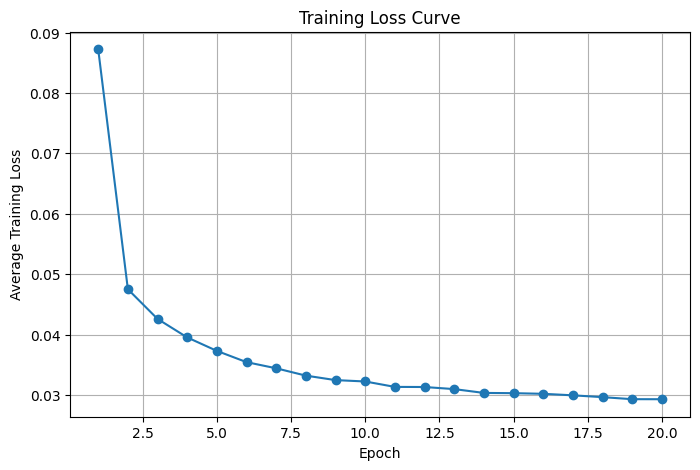

In [13]:
plt.figure(figsize=(8,5))
plt.plot(df_history["epoch"], df_history["avg_train_loss"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [14]:
best_ckpt = torch.load(os.path.join(CKPT_DIR, "best.pt"), map_location=device)
model.load_state_dict(best_ckpt["model"])
model.eval()

print("Loaded best model from epoch:", best_ckpt["epoch"])
print("Best loss:", best_ckpt["avg_loss"])

Loaded best model from epoch: 20
Best loss: 0.029296244004133668


In [15]:
results = []

start = time.time()
samples_ddpm = sample_ddpm(model, diff, n=16)
ddpm_time = time.time() - start
ddpm_path = os.path.join(RESULT_DIR, "final_ddpm_300.png")
save_image(make_grid(samples_ddpm, nrow=4), ddpm_path)

results.append({
    "method": "DDPM",
    "steps": 300,
    "time_sec": ddpm_time,
    "image_path": ddpm_path
})

for steps in [100, 50, 20]:
    start = time.time()
    samples_ddim = sample_ddim(model, diff, n=16, ddim_steps=steps, eta=0.0)
    ddim_time = time.time() - start

    out_path = os.path.join(RESULT_DIR, f"final_ddim_{steps}.png")
    save_image(make_grid(samples_ddim, nrow=4), out_path)

    results.append({
        "method": "DDIM",
        "steps": steps,
        "time_sec": ddim_time,
        "image_path": out_path
    })

df_compare = pd.DataFrame(results)
display(df_compare)

DDPM 300 steps:   0%|          | 0/300 [00:00<?, ?it/s]

DDIM 100 steps:   0%|          | 0/100 [00:00<?, ?it/s]

DDIM 50 steps:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM 20 steps:   0%|          | 0/20 [00:00<?, ?it/s]

,method,steps,time_sec,image_path
0,DDPM,300,1.087300,/content/drive/MyDrive/Colab Notebooks/CSE499B...
1,DDIM,100,0.422270,/content/drive/MyDrive/Colab Notebooks/CSE499B...
2,DDIM,50,0.218414,/content/drive/MyDrive/Colab Notebooks/CSE499B...
3,DDIM,20,0.098094,/content/drive/MyDrive/Colab Notebooks/CSE499B...


In [16]:
compare_csv = os.path.join(RESULT_DIR, "final_ddpm_vs_ddim.csv")
df_compare.to_csv(compare_csv, index=False)
print("Saved comparison CSV:", compare_csv)

Saved comparison CSV: /content/drive/MyDrive/Colab Notebooks/CSE499B_next_step/results/final_ddpm_vs_ddim.csv


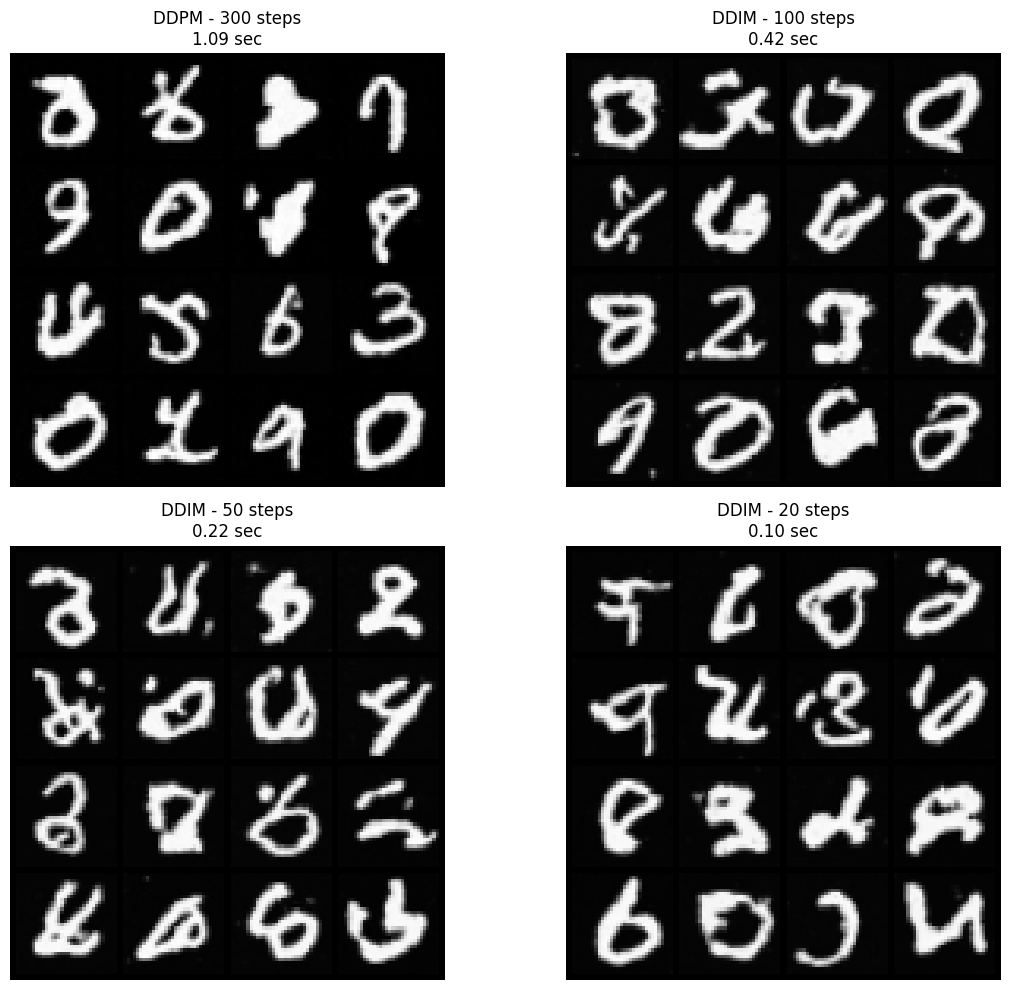

In [17]:
from PIL import Image

plt.figure(figsize=(12,10))

for idx, row in enumerate(results):
    img = Image.open(row["image_path"])
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"{row['method']} - {row['steps']} steps\n{row['time_sec']:.2f} sec")

plt.tight_layout()
plt.show()

In [18]:
summary = {
    "best_epoch": int(best_ckpt["epoch"]),
    "best_loss": float(best_ckpt["avg_loss"]),
    "num_epochs": EPOCHS,
    "dataset": "MNIST",
    "image_size": 32,
    "diffusion_steps": diff.T
}

summary_path = os.path.join(RESULT_DIR, "experiment_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Summary saved to:", summary_path)
print(summary)

Summary saved to: /content/drive/MyDrive/Colab Notebooks/CSE499B_next_step/results/experiment_summary.json
{'best_epoch': 20, 'best_loss': 0.029296244004133668, 'num_epochs': 20, 'dataset': 'MNIST', 'image_size': 32, 'diffusion_steps': 300}
